**Task 1 — Data Loading & Exploration**

In [1]:
import pandas as pd

In [2]:
data=pd.read_csv("Housing.csv")

In [3]:
data.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [4]:
data.shape

(545, 13)

In [156]:
#545 Rows and 13 Columns

In [5]:
target=data["price"]
target

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

In [38]:
features=data.iloc[:,1:13] # All cols except 1st
features

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...
540,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [157]:
#Target is price and other are Features

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [162]:
#No Missing Values since all 545 all are not null

**Task 2 — Data Cleaning**

In [158]:
'''There is no missing value 
if there was a missing value then we can drop that row or can fill na by its mean
in this case filling it by its mean was most sutaible beause of less data'''

'There is no missing value \nif there was a missing value then we can drop that row or can fill na by its mean\nin this case filling it by its mean was most sutaible beause of less data'

In [159]:
set(data.duplicated())

{False}

In [160]:
"""No duplicate rows since set have only one value false 
if there were duplicates then we will use data.drop_duplicates()"""

'No duplicate rows since set have only one value false \nif there were duplicates then we will use data.drop_duplicates()'

In [161]:
#We shold prefer binary encoder for yes no data but it is told to use one hot encoder 

In [9]:
from sklearn.preprocessing import OneHotEncoder

In [10]:
cat_cols=["mainroad","guestroom","basement","hotwaterheating","airconditioning","prefarea","furnishingstatus"]
cat_encoder=OneHotEncoder(sparse_output=False)
housing_categorical_encode=cat_encoder.fit_transform(data[cat_cols])
df_encoded=pd.DataFrame(housing_categorical_encode,columns=cat_encoder.get_feature_names_out(cat_cols))
df_encoded

,mainroad_no,mainroad_yes,guestroom_no,guestroom_yes,basement_no,basement_yes,hotwaterheating_no,hotwaterheating_yes,airconditioning_no,airconditioning_yes,prefarea_no,prefarea_yes,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
1,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
2,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
4,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
541,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
542,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
543,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [11]:
housing_data=data.join(df_encoded)
housing_data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,...,basement_yes,hotwaterheating_no,hotwaterheating_yes,airconditioning_no,airconditioning_yes,prefarea_no,prefarea_yes,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,yes,no,no,no,yes,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
1,12250000,8960,4,4,4,yes,no,no,no,yes,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
2,12250000,9960,3,2,2,yes,no,yes,no,no,...,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,12215000,7500,4,2,2,yes,no,yes,no,yes,...,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,...,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,...,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
541,1767150,2400,3,1,1,no,no,no,no,no,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
542,1750000,3620,2,1,1,yes,no,no,no,no,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
543,1750000,2910,3,1,1,no,no,no,no,no,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [12]:
train_and_testing_data=housing_data.drop(cat_cols,axis=1)
train_and_testing_data

,price,area,bedrooms,bathrooms,stories,parking,mainroad_no,mainroad_yes,guestroom_no,guestroom_yes,...,basement_yes,hotwaterheating_no,hotwaterheating_yes,airconditioning_no,airconditioning_yes,prefarea_no,prefarea_yes,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
1,12250000,8960,4,4,4,3,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
2,12250000,9960,3,2,2,2,0.0,1.0,1.0,0.0,...,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,12215000,7500,4,2,2,3,0.0,1.0,1.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
4,11410000,7420,4,1,2,2,0.0,1.0,0.0,1.0,...,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2,0.0,1.0,1.0,0.0,...,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
541,1767150,2400,3,1,1,0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
542,1750000,3620,2,1,1,0,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
543,1750000,2910,3,1,1,0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [163]:
#Now string colums are not important so we will drop them 

**Task 3 — Model Building**

In [31]:
import numpy as np

In [32]:
shuffel_indices=np.random.permutation(len(train_and_testing_data))
test_set_size=int(len(train_and_testing_data)*0.2)
test_indices=shuffel_indices[:test_set_size]
train_indices=shuffel_indices[test_set_size:]
train_data=train_and_testing_data.iloc[train_indices]
test_data=train_and_testing_data.iloc[test_indices]

In [43]:
train_data_features=train_data.iloc[:,1:] 
train_data_target=train_data["price"]
test_data_features=test_data.iloc[:,1:]
test_data_target=test_data["price"]

In [49]:
from sklearn.linear_model import LinearRegression
linear_modal=LinearRegression()
linear_modal.fit(train_data_features,train_data_target)

LinearRegression()

In [50]:
linear_predicted=linear_modal.predict(test_data_features) 
linear_predicted

array([3714881.47387577, 4515151.56291567, 3052932.13451569,
       3949749.92943662, 2901399.66588306, 2782056.46300914,
       5135947.93843607, 6005476.0666679 , 3903869.48565724,
       2588913.54529656, 5316350.05754977, 2678684.25100144,
       3503285.52479242, 7487695.75791205, 4137344.43079848,
       3667878.82985675, 4998956.99430706, 4278113.95320122,
       4106942.88815307, 4069838.38633987, 3373209.69910257,
       6062831.95421826, 4258717.17104613, 3852351.22297649,
       3259657.34413019, 4989685.85761599, 1989591.87135035,
       4312622.42386183, 7250066.41991884, 3682526.01006531,
       3907672.62511183, 3088779.40947118, 6570488.88380403,
       5706624.19732081, 4049988.55869702, 5143108.77369833,
       3972365.64893111, 4782256.12854284, 2986346.12443982,
       4813170.38094293, 5025517.45219176, 3972647.58781359,
       6768303.07154145, 7887014.24863008, 2655237.90942071,
       2466513.8961329 , 4289571.56610642, 3736626.35643902,
       5893504.30713856,

In [61]:
from sklearn.metrics import root_mean_squared_error,mean_absolute_error,r2_score

In [62]:
mae_linear=mean_absolute_error(test_data_target,linear_predicted)
rmse_linear=root_mean_squared_error(test_data_target,linear_predicted)
r2_linear=r2_score(test_data_target,linear_predicted)
print(f"MAE: {mae_linear} \nRMSE:{rmse_linear} \nR2: {r2_linear}")

MAE: 757355.2425637611 
RMSE:1051430.903175225 
R2: 0.6178808076503712


In [64]:
from sklearn.ensemble import RandomForestRegressor
forest_modal=RandomForestRegressor()
forest_modal.fit(train_data_features,train_data_target)

RandomForestRegressor()

In [66]:
forest_predicted=forest_modal.predict(test_data_features) 

In [67]:
mae_forest=mean_absolute_error(test_data_target,forest_predicted)
rmse_forest=root_mean_squared_error(test_data_target,forest_predicted)
r2_forest=r2_score(test_data_target,forest_predicted)
print(f"MAE: {mae_forest} \nRMSE:{rmse_forest} \nR2: {r2_forest}")

MAE: 824662.1709480124 
RMSE:1183384.2979385313 
R2: 0.5159513858233626


In [164]:
#By this Modal 1 (Linear Modal) is much better because of smaller MAE and RMSE and also higher R2

**Task 4 — Visualization (Minimum 3 charts)**

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

<Figure size 800x640 with 0 Axes>

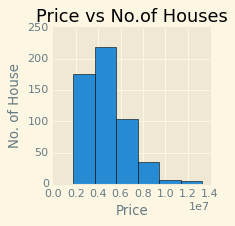

<Figure size 800x640 with 0 Axes>

In [115]:
plt.hist(data["price"],bins=6,edgecolor="black")
plt.title("Price vs No.of Houses")
plt.xlabel("Price")
plt.ylabel("No. of House")
plt.style.use("Solarize_Light2")
plt.figure(figsize=(10,8))

<Figure size 800x640 with 0 Axes>

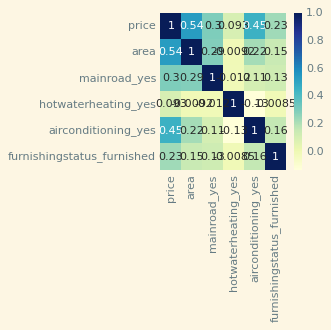

<Figure size 800x640 with 0 Axes>

In [132]:
cols=["price","area","mainroad_yes","hotwaterheating_yes","airconditioning_yes","furnishingstatus_furnished"]
corr_data=train_and_testing_data[cols]
corr_mat=corr_data.corr()
sns.heatmap(corr_mat,annot=True,cmap="YlGnBu")
plt.figure(figsize=(10,8))

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'area'}>],
       [<Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'bathrooms'}>],
       [<Axes: title={'center': 'stories'}>,
        <Axes: title={'center': 'parking'}>]], dtype=object)

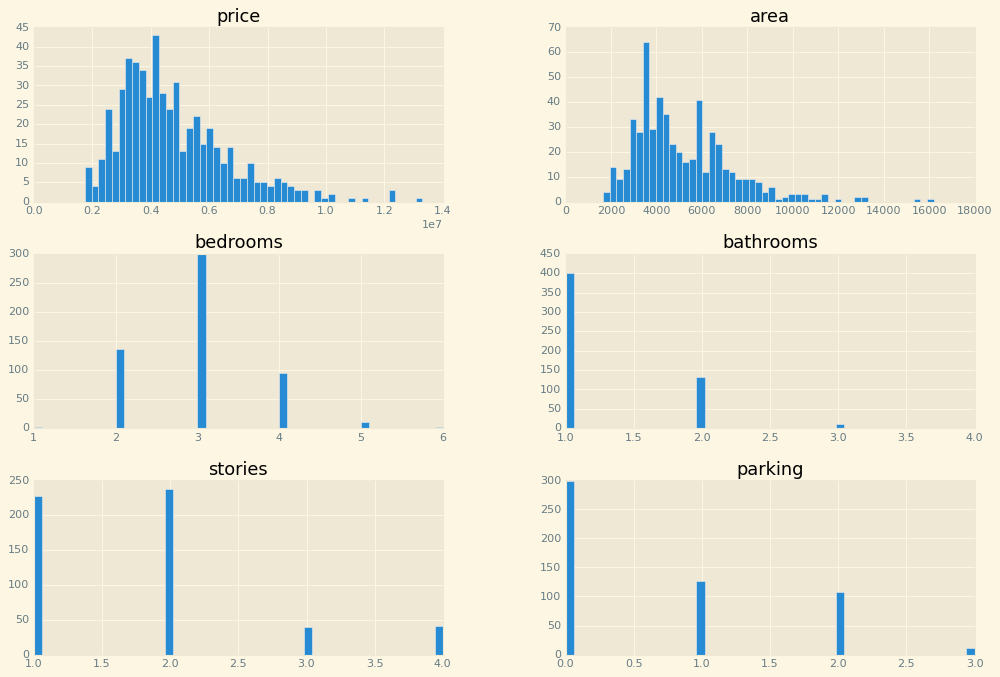

In [141]:
data.hist(bins=50,figsize=(12,8))

Text(0, 0.5, 'Actutal Price')

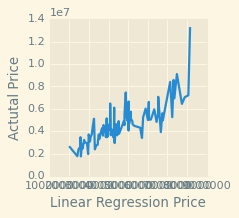

In [151]:
sns.lineplot(x=linear_predicted,y=test_data_target)
plt.xlabel("Linear Regression Price")
plt.ylabel("Actutal Price")

Text(0, 0.5, 'Actutal Price')

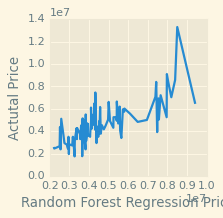

In [155]:
sns.lineplot(x=forest_predicted,y=test_data_target)
# plt.figure(figsize=(10,6))
# plt.scatter(forest_predicted,test_data_target)
# plt.title("Random Forest Regession Predicted Price vs Actual Price")
plt.xlabel("Random Forest Regression Price")
plt.ylabel("Actutal Price")

**Task 5 — Insights & Summary**

In [ ]:
#Property area and key amenities (like air conditioning and bathrooms) are the strongest drivers of house prices.
#The Linear Regression model was fairly accurate, explaining about 62% of the price variations (R² ≈ 0.618).
#It was surprising to see the simpler Linear Regression model outperform the more complex Random Forest Regressor on this dataset.
#Real estate businesses should prioritize core metrics like total area in their valuations and can rely on simple linear models for quick, baseline price estimates.